In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dataset
df = pd.read_csv('heart.csv')

# Verifica caricamento
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


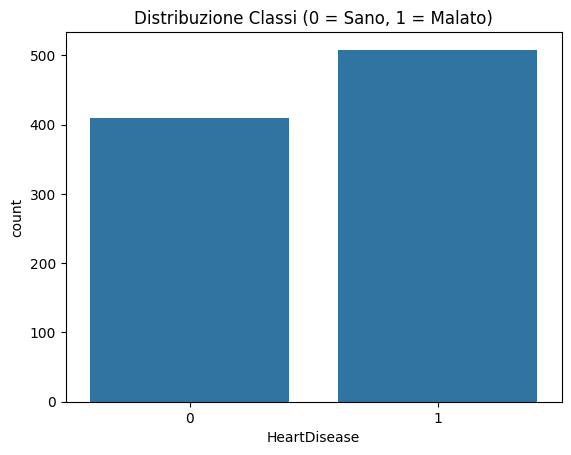

In [191]:
# Controllo sui dati
print(df.info())

# Controllo distribuzione della classe target
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuzione Classi (0 = Sano, 1 = Malato)')
plt.show()

Inizio Operazioni di pre-processing

1. Identificazione valori nulli o non validi

In [192]:
print("Zeri nel colesterolo:", (df['Cholesterol'] == 0).sum())

Zeri nel colesterolo: 172


In [193]:
# Calcolo di media e mediana senza escludere gli 0 (valori non validi)
mean_with_zeros = df['Cholesterol'].mean()
median_with_zeros = df['Cholesterol'].median()

# Calcolo di media e mediana senza escludere gli 0
# Lista di istanze con colesterolo diverso da 0
chol_filtered = df[df['Cholesterol'] > 0]['Cholesterol']

mean_real = chol_filtered.mean()
median_real = chol_filtered.median()

print("--- ANALISI VALORI COLESTEROLO ---")
print(f"Media (con zeri): {mean_with_zeros:.2f}")
print(f"Mediana (con zeri): {median_with_zeros:.2f}")
print("")
print(f"Media (SENZA zeri): {mean_real:.2f} ")
print(f"Mediana (SENZA zeri): {median_real:.2f} ")
print("")

--- ANALISI VALORI COLESTEROLO ---
Media (con zeri): 198.80
Mediana (con zeri): 223.00

Media (SENZA zeri): 244.64 
Mediana (SENZA zeri): 237.00 



In [194]:
# Sostituzione valori non validi
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

2. Codifica delle variabili categoriche

In [195]:
# Identificazione colonne categoriche
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# One-Hot Encoding, drop_first=true per evitare ridondanza di feature
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [196]:
print(f"Formato originale: {df.shape}")
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Formato dopo One-Hot Encoding: {df_encoded.shape}")

Formato originale: (918, 12)
Formato dopo One-Hot Encoding: (918, 16)


3. Suddivisione classi per addestramento e training

In [197]:
from sklearn.model_selection import train_test_split

# Caratteristiche
X = df_encoded.drop('HeartDisease', axis=1)

# Target
y = df_encoded['HeartDisease']

#Riproducibilità risultati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dati di addestramento: {X_train.shape[0]}")
print(f"Dati di test: {X_test.shape[0]}")

Dati di addestramento: 734
Dati di test: 184


4. Identificazione di outlier

In [198]:
risultato = df[df['Cholesterol'] > 400]
print(risultato)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
28    53   F           ATA        113          468          0     Normal   
30    53   M           NAP        145          518          0     Normal   
69    44   M           ASY        150          412          0     Normal   
76    32   M           ASY        118          529          0     Normal   
103   40   M           ASY        120          466          1     Normal   
149   54   M           ASY        130          603          1     Normal   
182   52   M           ASY        140          404          0     Normal   
250   44   M           ASY        135          491          0     Normal   
496   58   M           ASY        132          458          1     Normal   
616   67   F           NAP        115          564          0        LVH   
624   63   F           ASY        150          407          0        LVH   
667   65   F           NAP        140          417          1        LVH   
796   56   F

In [199]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Applicazione scaler alle feature
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Esempio di dati scalati:")
print(X_train_scaled[:2])

Esempio di dati scalati:
[[-1.24506731 -0.70898547 -0.02551757  1.84260945  2.28435288 -0.09706109
   0.54060477 -0.48333575  1.87905939 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003 -0.84792072]
 [-1.8862362  -0.16628515 -0.63096791 -0.5427086   1.65224147 -0.83628643
   0.54060477 -0.48333575  1.87905939 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003  1.17935554]]


In [200]:
import numpy as np

# Controllo risultati dello scaling sulle istanze dove vi erano outlier
mask = (X_train['Cholesterol'] > 400).values
righe_scalate = X_train_scaled[mask]

print(f"Trovate {len(righe_scalate)} istanze con colesterolo > 400.")
print(righe_scalate)

Trovate 8 istanze con colesterolo > 400.
[[-1.03134434  0.91911549  3.33375524 -0.5427086   1.33618577 -0.83628643
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003  1.17935554]
 [-0.06959099 -1.0888757   4.42747196 -0.5427086  -0.36261364 -0.83628643
  -1.84978019  2.06895518 -0.53218116 -0.21350421  0.80817891 -0.48762079
  -0.83846064 -1.03325003  1.17935554]
 [-0.17645248  0.37641517  3.17750999 -0.5427086  -0.48113453  1.01177691
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
   1.19266183  0.96781995 -0.84792072]
 [ 0.03727049 -0.16628515  7.06411051  1.84260945 -0.44162756  0.08774524
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
   1.19266183  0.96781995 -0.84792072]
 [-1.45879027 -0.70898547  4.38841065  1.84260945  0.62506044  0.08774524
   0.54060477 -0.48333575 -0.53218116 -0.21350421  0.80817891 -0.48762079
   1.19266183  0.96781995 -0.84792072]
 [ 0.99902384  0.9191154

Fase di addestramento del modello e analisi delle performance

1. Logistic Regression

--- PERFORMANCE DEL MODELLO ---
Accuracy:  0.8641
Precision: 0.9100
Recall:    0.8505
F1-Score:  0.8792


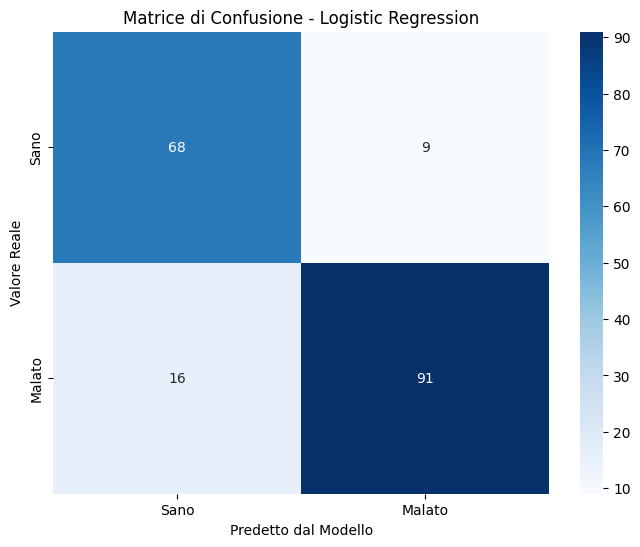

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Addestramento del modello
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)

# Predizione
y_pred = model_lr.predict(X_test_scaled)

# Calcolo delle metriche di valutazione
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Stampa dei risultati in valori numerici
print("--- PERFORMANCE DEL MODELLO ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Grafico della matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sano', 'Malato'], yticklabels=['Sano', 'Malato'])
plt.xlabel('Predetto dal Modello')
plt.ylabel('Valore Reale')
plt.title('Matrice di Confusione - Logistic Regression')
plt.show()

2. Random Forest

--- PERFORMANCE RANDOM FOREST ---
Accuracy:  0.8696
Precision: 0.8879
Recall:    0.8879
F1-Score:  0.8879


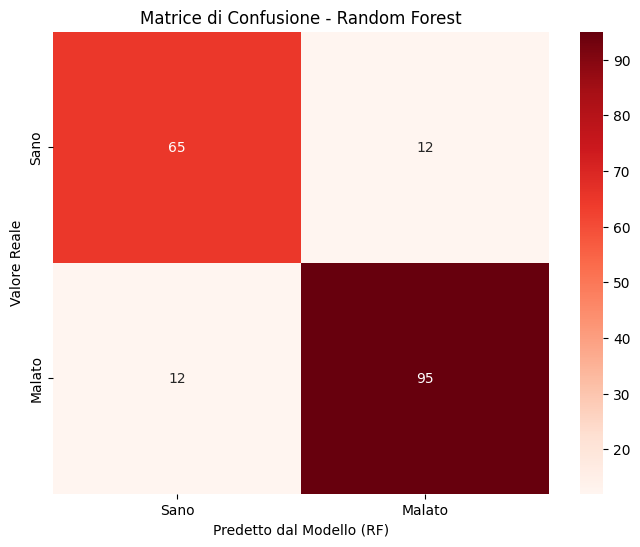

In [202]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Addestramento del modello
# Usiamo 100 alberi (n_estimators) e un random_state per rendere i risultati replicabili
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Predizione
y_pred_rf = model_rf.predict(X_test_scaled)

# Calcolo delle metriche di valutazione
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Stampa dei risultati in valori numerici
print("--- PERFORMANCE RANDOM FOREST ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

# Grafico della matrice di Confusione
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Sano', 'Malato'], yticklabels=['Sano', 'Malato'])
plt.xlabel('Predetto dal Modello (RF)')
plt.ylabel('Valore Reale')
plt.title('Matrice di Confusione - Random Forest')
plt.show()

Feature più importanti del Random Forest

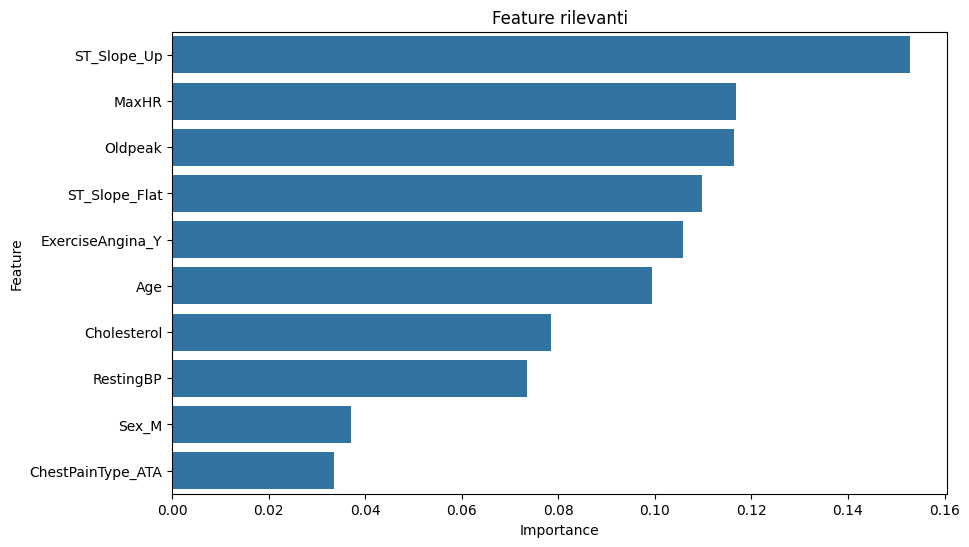

In [203]:
# Estrazione feature più rilevanti per il modello Random Forest
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Grafico delle feature più importanti
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Feature rilevanti')
plt.show()

3. SVC

--- PERFORMANCE SVM ---
Accuracy:  0.8478
Precision: 0.8762
Recall:    0.8598
F1-Score:  0.8679


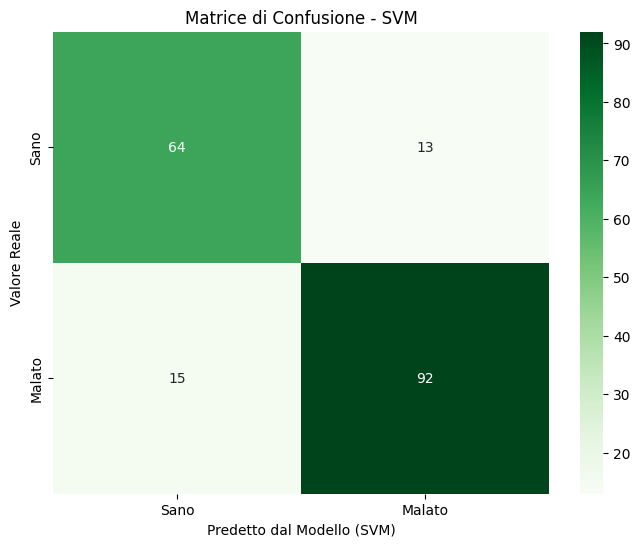

In [204]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Addestramento del modello SVM
model_svm = SVC(kernel='rbf', probability=True, random_state=42)
model_svm.fit(X_train_scaled, y_train)

# 2. Predizione
y_pred_svm = model_svm.predict(X_test_scaled)

# 3. Calcolo delle metriche di valutazione
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# 4. Stampa dei risultati
print("--- PERFORMANCE SVM ---")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")

# 5. Grafico della matrice di Confusione
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sano', 'Malato'], yticklabels=['Sano', 'Malato'])
plt.xlabel('Predetto dal Modello (SVM)')
plt.ylabel('Valore Reale')
plt.title('Matrice di Confusione - SVM')
plt.show()

Rappresentazione grafica delle prestazioni con curve ROC

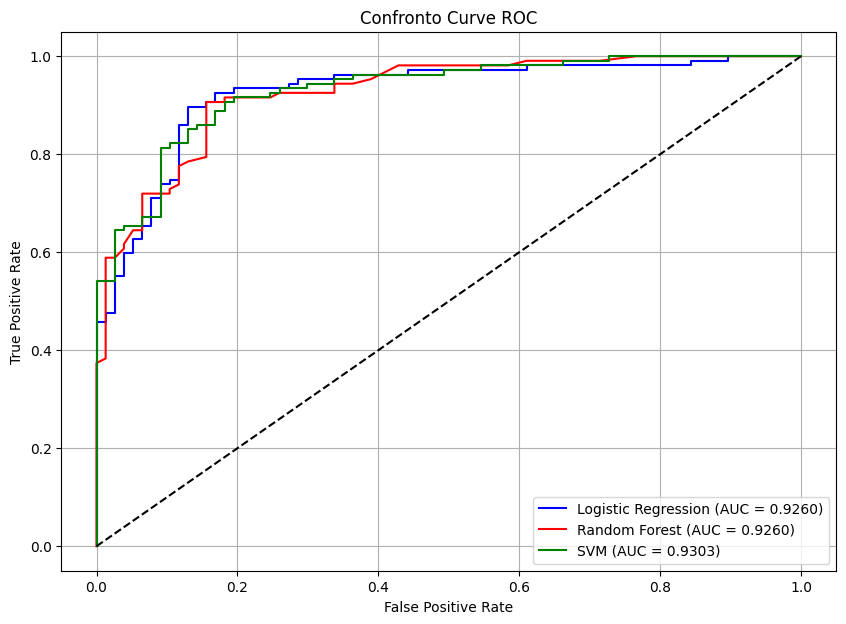

In [205]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcolo delle probabilità per le curve ROC
y_probs_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
y_probs_rf = model_rf.predict_proba(X_test_scaled)[:, 1]
y_probs_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

# Calcolo dei tassi di falsi positivi e veri positivi
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_probs_svm)

# Grafico curve ROC
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_probs_lr):.4f})')
plt.plot(fpr_rf, tpr_rf, color='red', label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs_rf):.4f})')
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM (AUC = {roc_auc_score(y_test, y_probs_svm):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Confronto Curve ROC')
plt.legend()
plt.grid(True)
plt.show()

Esportazione dataset modificato

In [206]:
from google.colab import files

df_encoded.to_csv('heart_disease_processed.csv', index=False)